In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [53]:
df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [54]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 145460
Columns: 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Clou

In [55]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [56]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [57]:
df = df.drop_duplicates()

In [58]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_percentage = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Values,Missing Percentage
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


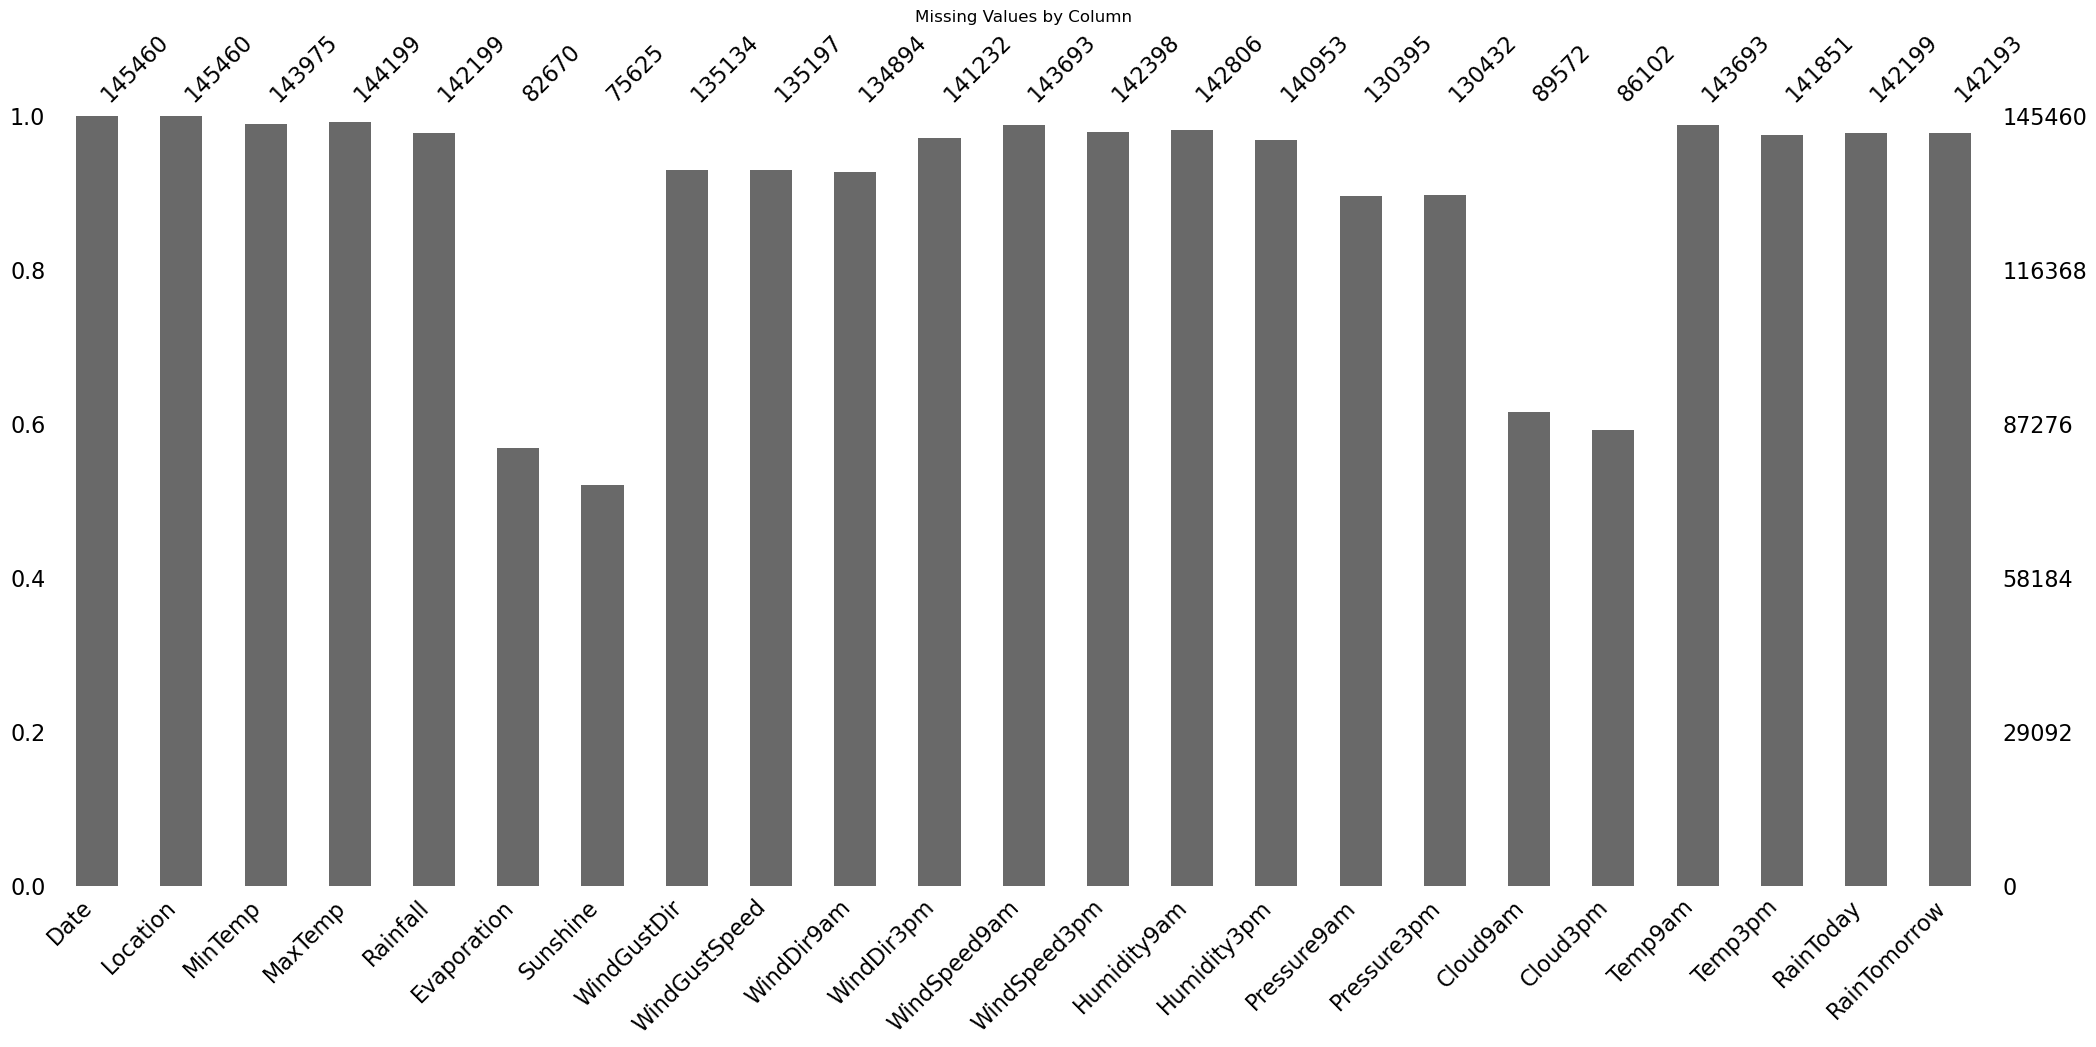

In [59]:
plt.figure(figsize=(14, 6))

msno.bar(df)

plt.title("Missing Values by Column")
plt.show()

<Figure size 1400x600 with 0 Axes>

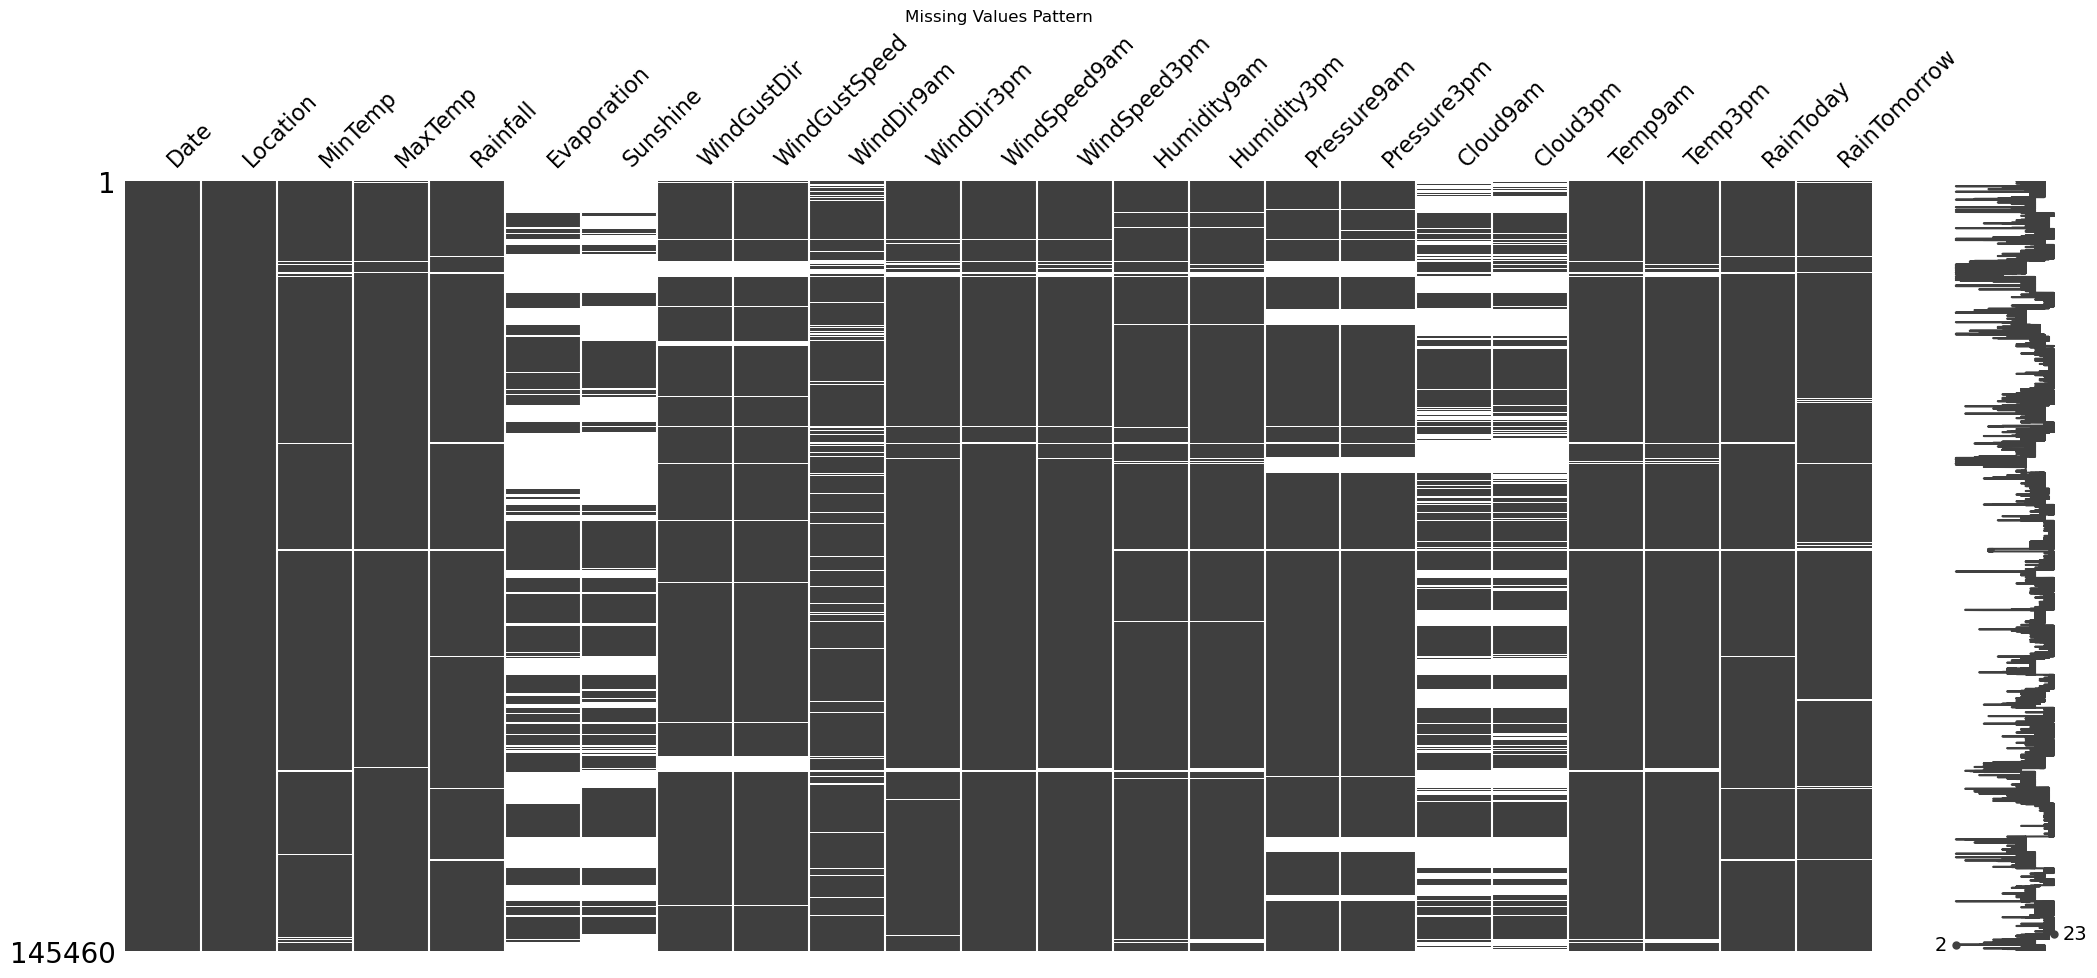

In [60]:
plt.figure(figsize=(14, 6))

msno.matrix(df)

plt.title("Missing Values Pattern")
plt.show()

In [61]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["Location", "Date"]).reset_index(drop=True)

In [62]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.day_name()

In [63]:
df[["Date", "Year", "Month", "Day", "DayOfWeek"]].head()

,Date,Year,Month,Day,DayOfWeek
0,2008-07-01,2008,7,1,Tuesday
1,2008-07-02,2008,7,2,Wednesday
2,2008-07-03,2008,7,3,Thursday
3,2008-07-04,2008,7,4,Friday
4,2008-07-05,2008,7,5,Saturday


In [64]:
df["RainToday"] = df["RainToday"].map({
    "No": 0,
    "Yes": 1
})

df["RainTomorrow"] = df["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

In [65]:
df[["RainToday", "RainTomorrow"]].head()

,RainToday,RainTomorrow
0,1.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,NaN


In [66]:
rain_counts = df["RainTomorrow"].value_counts(dropna=False)

rain_counts

RainTomorrow
0.0    110316
1.0     31877
NaN      3267
Name: count, dtype: int64

In [67]:
df["RainTomorrow"].value_counts(normalize=True, dropna=False) * 100

RainTomorrow
0.0    75.839406
1.0    21.914616
NaN     2.245978
Name: proportion, dtype: float64

In [68]:
print("Number of locations:", df["Location"].nunique())

df["Location"].value_counts()

Number of locations: 49


Location
Canberra            3436
Sydney              3344
Adelaide            3193
Melbourne           3193
Perth               3193
Hobart              3193
Brisbane            3193
Darwin              3193
Albany              3040
Launceston          3040
GoldCoast           3040
Townsville          3040
MountGambier        3040
Cairns              3040
Bendigo             3040
Ballarat            3040
Wollongong          3040
AliceSprings        3040
Albury              3040
MountGinini         3040
Tuggeranong         3039
Penrith             3039
Newcastle           3039
Moree               3009
Sale                3009
BadgerysCreek       3009
Witchcliffe         3009
Williamtown         3009
Watsonia            3009
WaggaWagga          3009
Cobar               3009
CoffsHarbour        3009
SydneyAirport       3009
Dartmoor            3009
Mildura             3009
Woomera             3009
Richmond            3009
Portland            3009
PerthAirport        3009
MelbourneAirport

In [69]:
df["TempAverage"] = (
    df["MinTemp"] + df["MaxTemp"]
) / 2

df["HumidityAverage"] = (
    df["Humidity9am"] + df["Humidity3pm"]
) / 2

df["PressureAverage"] = (
    df["Pressure9am"] + df["Pressure3pm"]
) / 2

df["CloudAverage"] = (
    df["Cloud9am"] + df["Cloud3pm"]
) / 2

df["WindSpeedAverage"] = (
    df["WindSpeed9am"] + df["WindSpeed3pm"]
) / 2

In [70]:
df["HumidityChange"] = (
    df["Humidity3pm"] - df["Humidity9am"]
)

df["PressureChange"] = (
    df["Pressure3pm"] - df["Pressure9am"]
)

df["CloudChange"] = (
    df["Cloud3pm"] - df["Cloud9am"]
)

df["WindSpeedChange"] = (
    df["WindSpeed3pm"] - df["WindSpeed9am"]
)

df["TempChange"] = (
    df["Temp3pm"] - df["Temp9am"]
)

In [71]:
df["Rain"] = (df["Rainfall"] >= 1).astype(int)

In [72]:
numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns].isnull().mean().mul(100).sort_values(ascending=False)

Sunshine            48.009762
CloudAverage        43.655988
CloudChange         43.655988
Evaporation         43.166506
Cloud3pm            40.807095
Cloud9am            38.421559
PressureAverage     10.510793
PressureChange      10.510793
Pressure9am         10.356799
Pressure3pm         10.331363
WindGustSpeed        7.055548
HumidityAverage      3.625739
HumidityChange       3.625739
Humidity3pm          3.098446
TempChange           2.919703
WindSpeedChange      2.485907
WindSpeedAverage     2.485907
Temp3pm              2.481094
RainTomorrow         2.245978
Rainfall             2.241853
RainToday            2.241853
WindSpeed3pm         2.105046
Humidity9am          1.824557
TempAverage          1.293139
Temp9am              1.214767
WindSpeed9am         1.214767
MinTemp              1.020899
MaxTemp              0.866905
Day                  0.000000
Month                0.000000
Year                 0.000000
Rain                 0.000000
dtype: float64

In [73]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    if column not in ["RainTomorrow", "RainToday", "Rain"]:
        df[column] = (
            df.groupby("Location")[column]
              .transform(lambda x: x.fillna(x.median()))
        )
        
        df[column] = df[column].fillna(df[column].median())

In [74]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [75]:
df.isnull().sum().sort_values(ascending=False)

RainTomorrow        3267
RainToday           3261
Date                   0
HumidityAverage        0
Year                   0
Month                  0
Day                    0
DayOfWeek              0
TempAverage            0
PressureAverage        0
Location               0
CloudAverage           0
WindSpeedAverage       0
HumidityChange         0
PressureChange         0
CloudChange            0
WindSpeedChange        0
TempChange             0
Temp3pm                0
Temp9am                0
Cloud3pm               0
Cloud9am               0
MinTemp                0
MaxTemp                0
Rainfall               0
Evaporation            0
Sunshine               0
WindGustDir            0
WindGustSpeed          0
WindDir9am             0
WindDir3pm             0
WindSpeed9am           0
WindSpeed3pm           0
Humidity9am            0
Humidity3pm            0
Pressure9am            0
Pressure3pm            0
Rain                   0
dtype: int64

In [76]:
df["RainTomorrow"].isnull().sum()

3267

In [77]:
numeric_columns = df.select_dtypes(include="number").columns

rain_correlation = (
    df[numeric_columns]
    .corr()["Rain"]
    .sort_values(ascending=False)
)

rain_correlation

Rain                1.000000
RainToday           0.965711
Rainfall            0.488826
HumidityAverage     0.397415
Humidity3pm         0.375023
Humidity9am         0.354025
RainTomorrow        0.306995
PressureChange      0.290801
CloudAverage        0.224082
Cloud9am            0.210796
Cloud3pm            0.192682
WindGustSpeed       0.144405
WindSpeedAverage    0.099678
WindSpeed9am        0.099084
WindSpeed3pm        0.077601
HumidityChange      0.068421
MinTemp             0.052153
Month               0.011914
Day                 0.003479
Year               -0.014692
WindSpeedChange    -0.019976
CloudChange        -0.043994
Pressure3pm        -0.095924
Temp9am            -0.101964
TempAverage        -0.104648
PressureAverage    -0.137202
Evaporation        -0.144273
Pressure9am        -0.175855
MaxTemp            -0.232256
Temp3pm            -0.236278
Sunshine           -0.244141
TempChange         -0.278629
Name: Rain, dtype: float64

In [93]:
rain_tomorrow_correlation = (
    df[numeric_columns]
    .corr()["RainTomorrow"]
    .sort_values(ascending=False)
)

rain_tomorrow_correlation

RainTomorrow        1.000000
Humidity3pm         0.440683
HumidityAverage     0.384010
RainToday           0.313097
Rain                0.306995
Cloud3pm            0.274850
CloudAverage        0.274011
HumidityChange      0.265105
Humidity9am         0.256604
Rainfall            0.235092
WindGustSpeed       0.224799
Cloud9am            0.223213
WindSpeedAverage    0.100087
WindSpeed9am        0.090204
WindSpeed3pm        0.086072
MinTemp             0.083483
PressureChange      0.076345
CloudChange         0.037069
Month               0.007328
Day                 0.005379
WindSpeedChange    -0.003676
Year               -0.012039
Temp9am            -0.027330
TempAverage        -0.047176
Evaporation        -0.091501
MaxTemp            -0.159142
Temp3pm            -0.191320
Pressure3pm        -0.214572
PressureAverage    -0.226286
Pressure9am        -0.233933
TempChange         -0.324131
Sunshine           -0.328694
Name: RainTomorrow, dtype: float64

In [91]:
df.groupby('Month')[['RainTomorrow','CloudAverage', 'HumidityAverage', 'Sunshine', 'TempChange']].mean().sort_values('RainTomorrow')

,RainTomorrow,CloudAverage,HumidityAverage,Sunshine,TempChange
Month,,,,,
1,0.193329,4.777010,54.628475,8.841818,5.120406
10,0.195696,4.667401,55.225515,8.468889,4.607840
12,0.208141,4.900929,54.626296,8.724844,4.452961
2,0.209691,4.814417,58.129297,8.519777,5.344835
11,0.212547,4.894078,55.000814,8.564761,4.370589
3,0.213332,4.834294,60.633486,8.010965,5.493676
4,0.217849,4.892208,61.585238,7.739823,4.616398
5,0.225278,4.863401,64.887591,7.383371,4.765910
9,0.229705,4.647294,57.824442,8.046933,3.926100


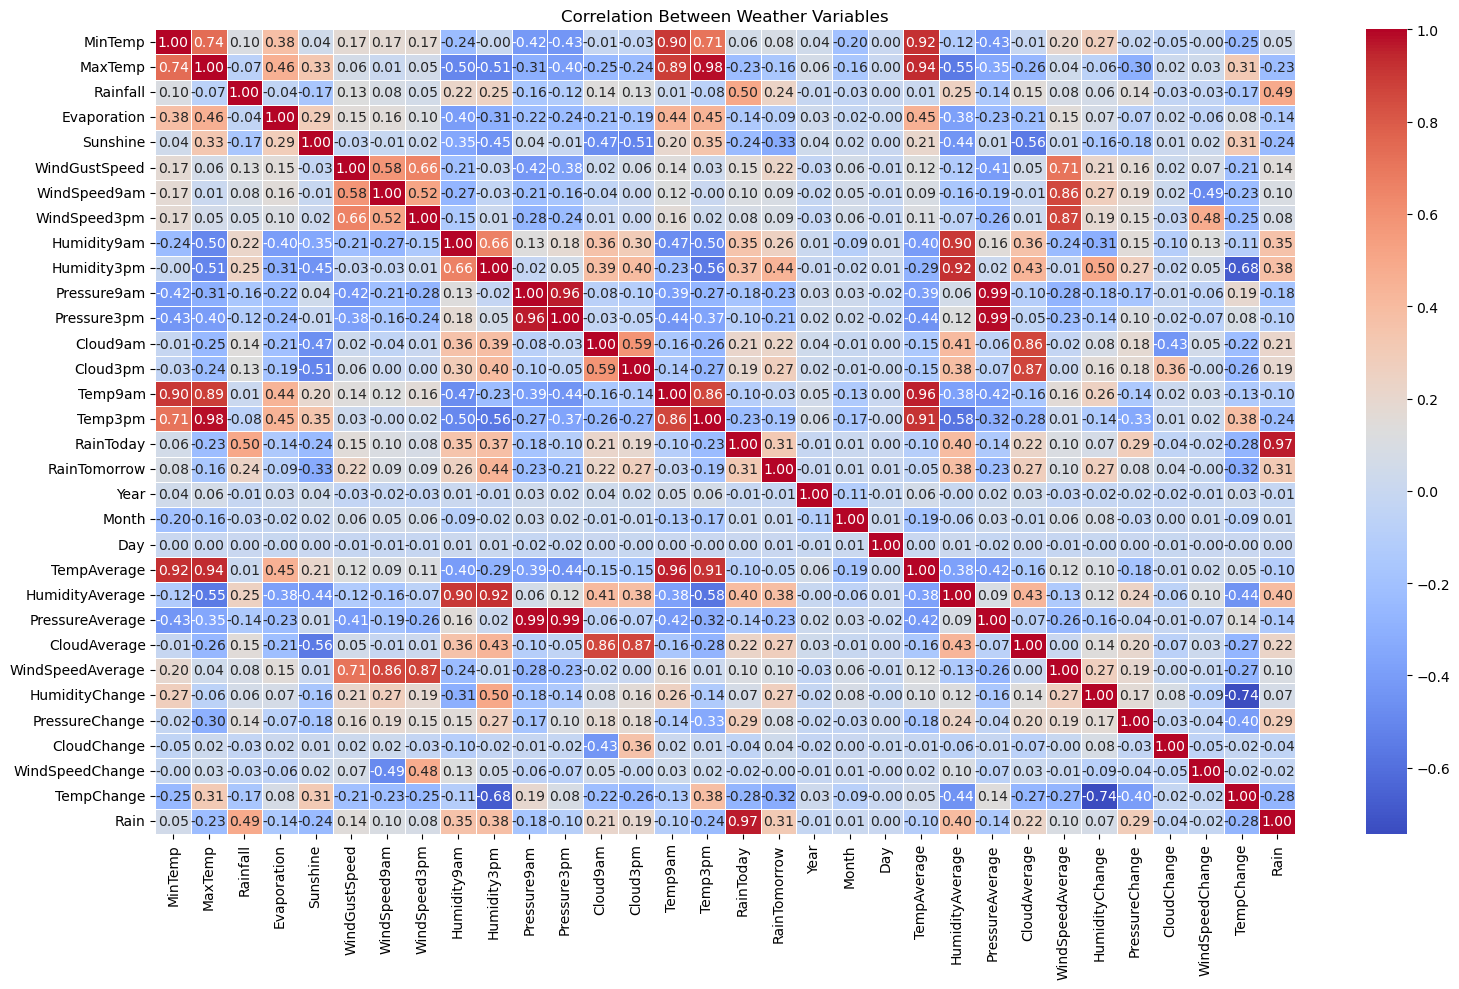

In [80]:
plt.figure(figsize=(16, 10))

corr_matrix = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Weather Variables")
plt.tight_layout()
plt.show()

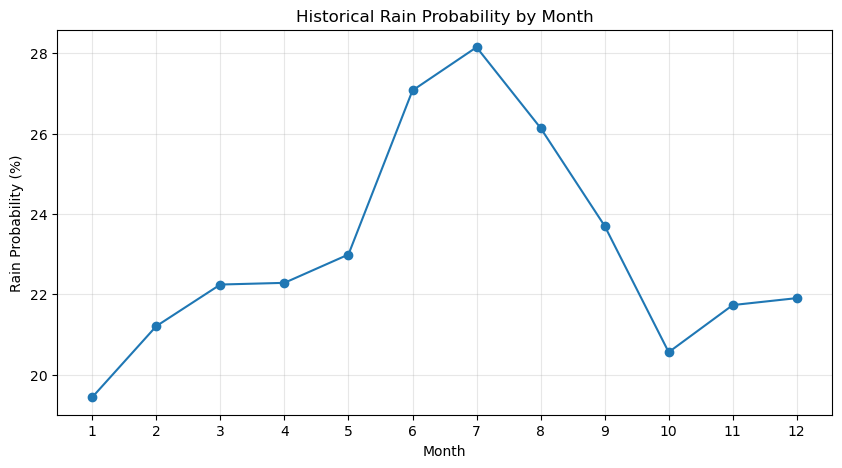

In [81]:
monthly_rain = (
    df.groupby("Month")["Rain"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_rain.index,
    monthly_rain.values,
    marker="o"
)

plt.xticks(range(1, 13))

plt.xlabel("Month")
plt.ylabel("Rain Probability (%)")
plt.title("Historical Rain Probability by Month")

plt.grid(alpha=0.3)
plt.show()

In [82]:
july = df[df["Month"] == 7].copy()

print("Historical July records:", len(july))

july.head()

Historical July records: 12025


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,HumidityAverage,PressureAverage,CloudAverage,WindSpeedAverage,HumidityChange,PressureChange,CloudChange,WindSpeedChange,TempChange,Rain
0,2008-07-01,Adelaide,8.8,15.7,5.0,1.6,2.6,NW,48.0,SW,...,79.5,1017.55,5.0,14.0,-25.0,0.3,0.0,2.0,1.4,1
1,2008-07-02,Adelaide,12.7,15.8,0.8,1.4,7.8,SW,35.0,SSW,...,63.5,1022.50,5.0,14.0,-23.0,0.2,0.0,2.0,1.8,0
2,2008-07-03,Adelaide,6.2,15.1,0.0,1.8,2.1,W,20.0,NNE,...,68.5,1027.15,5.0,6.5,-25.0,-1.3,0.0,9.0,4.6,0
3,2008-07-04,Adelaide,5.3,15.9,0.0,1.4,8.0,NNE,30.0,NNE,...,58.5,1027.15,5.0,9.5,-25.0,-3.1,0.0,7.0,5.1,0
4,2008-07-05,Adelaide,9.8,15.4,0.0,4.2,0.9,N,30.0,NNE,...,61.5,1021.90,5.0,9.0,11.0,-3.4,0.0,0.0,2.5,0


In [83]:
july_rain_probability = july["Rain"].mean() * 100

print(f"Historical July rain probability: {july_rain_probability:.2f}%")

Historical July rain probability: 28.15%


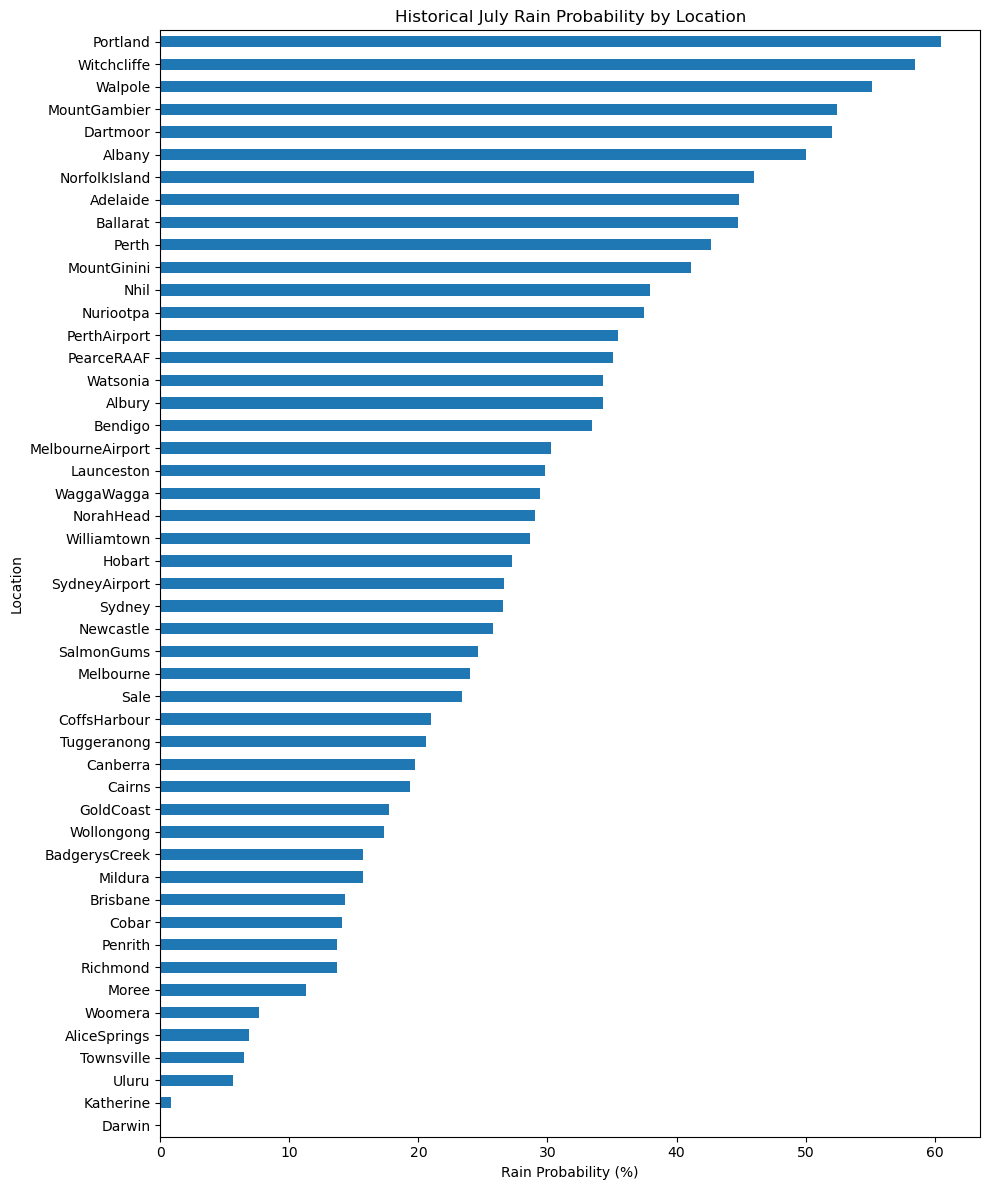

In [84]:
july_location_rain = (
    july.groupby("Location")["Rain"]
         .mean()
         .mul(100)
         .sort_values(ascending=True)
)

plt.figure(figsize=(10, 12))

july_location_rain.plot(kind="barh")

plt.xlabel("Rain Probability (%)")
plt.ylabel("Location")
plt.title("Historical July Rain Probability by Location")

plt.tight_layout()
plt.show()

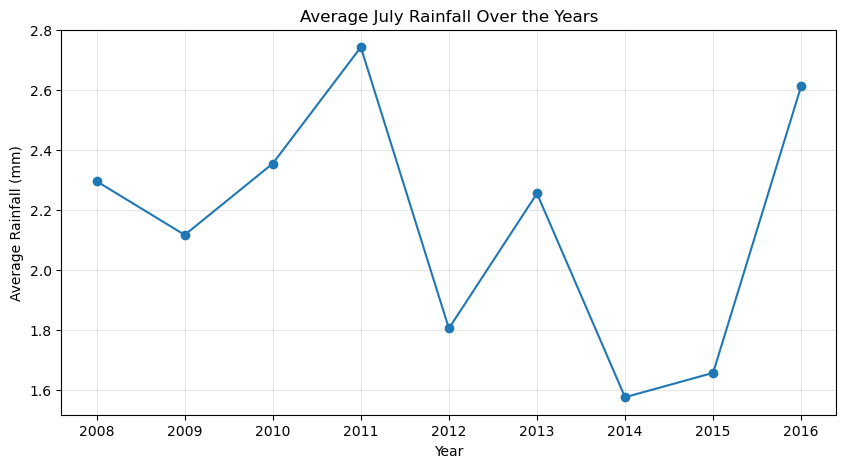

In [85]:
july_yearly = (
    july.groupby("Year")["Rainfall"]
        .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    july_yearly.index,
    july_yearly.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Rainfall (mm)")
plt.title("Average July Rainfall Over the Years")

plt.grid(alpha=0.3)
plt.show()

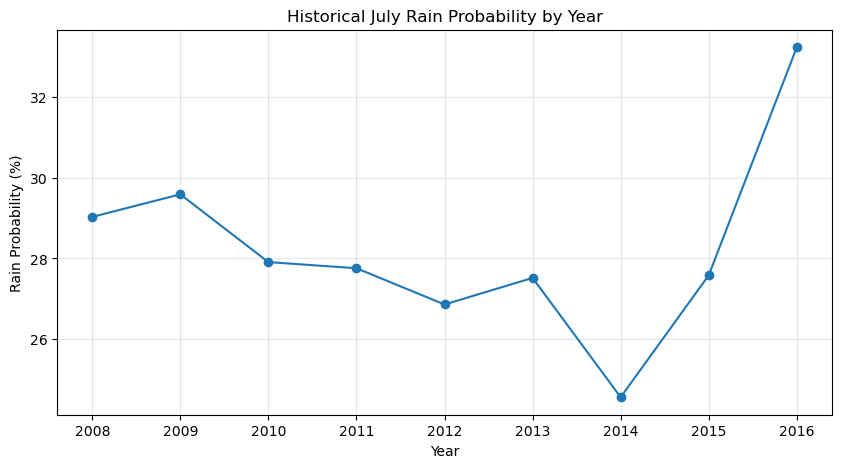

In [86]:
july_yearly_probability = (
    july.groupby("Year")["Rain"]
        .mean()
        .mul(100)
)

plt.figure(figsize=(10, 5))

plt.plot(
    july_yearly_probability.index,
    july_yearly_probability.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Rain Probability (%)")
plt.title("Historical July Rain Probability by Year")

plt.grid(alpha=0.3)
plt.show()

In [87]:
weather_comparison = (
    df.groupby("Rain")[
        [
            "TempAverage",
            "HumidityAverage",
            "PressureAverage",
            "CloudAverage",
            "WindSpeedAverage"
        ]
    ]
    .mean()
)

weather_comparison.index = ["No Rain", "Rain"]

weather_comparison

,TempAverage,HumidityAverage,PressureAverage,CloudAverage,WindSpeedAverage
No Rain,18.058804,56.382218,1016.950921,4.563423,15.844019
Rain,16.501949,73.297140,1014.794474,5.647210,17.658774


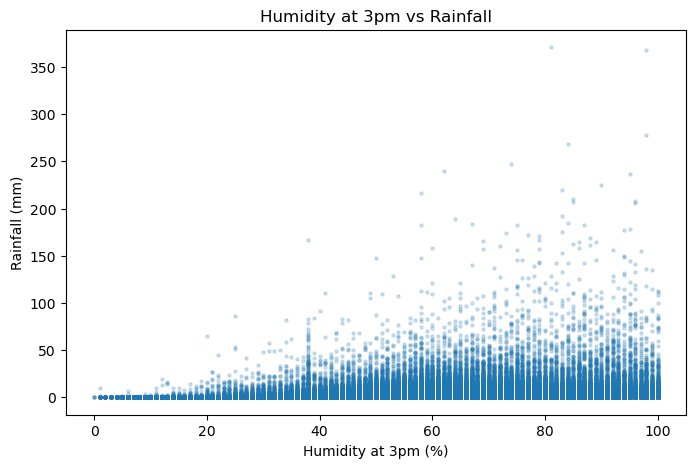

In [88]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Humidity3pm"],
    df["Rainfall"],
    alpha=0.2,
    s=5
)

plt.xlabel("Humidity at 3pm (%)")
plt.ylabel("Rainfall (mm)")
plt.title("Humidity at 3pm vs Rainfall")

plt.show()

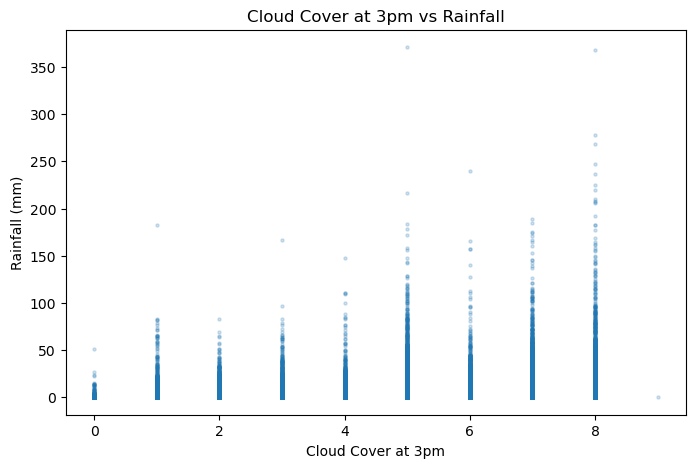

In [89]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Cloud3pm"],
    df["Rainfall"],
    alpha=0.2,
    s=5
)

plt.xlabel("Cloud Cover at 3pm")
plt.ylabel("Rainfall (mm)")
plt.title("Cloud Cover at 3pm vs Rainfall")

plt.show()

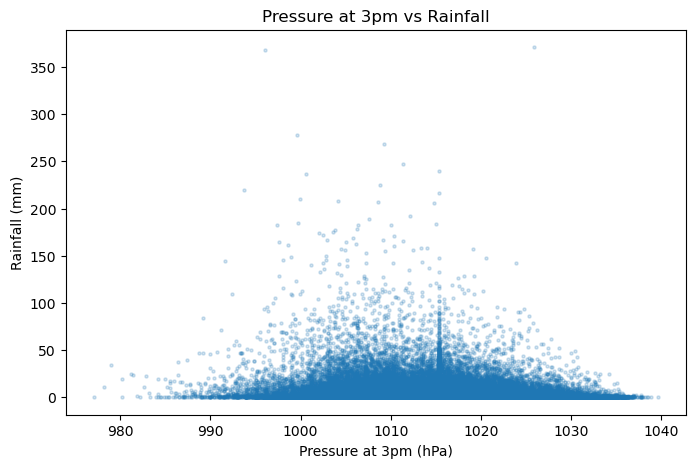

In [90]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Pressure3pm"],
    df["Rainfall"],
    alpha=0.2,
    s=5
)

plt.xlabel("Pressure at 3pm (hPa)")
plt.ylabel("Rainfall (mm)")
plt.title("Pressure at 3pm vs Rainfall")

plt.show()